<a href="https://colab.research.google.com/github/martinthuriaux/Auto-Interp-Causal-Validation/blob/main/02_exemplars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/martinthuriaux/CNN-Watch-vs-Do/blob/main/02_exemplars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Exemplar grids

Here we want to build one exemplar grid per unit, ie a a 4x4 image of its 16 favorites, each cropped to
   the unit's *receptive field* around the recorded peak, so the future labelers describe the
   unit's trigger rather than the whole scene.


## 0. Session bootstrap + guards

Same guard discipline as `01`: assert the GPU, load the frozen config, ensure datasets and
the completed top-16 checkpoint are present.

In [ ]:
import os, json, hashlib, shutil, tarfile, pickle, urllib.request
from pathlib import Path
import numpy as np
from PIL import Image
import torch

assert torch.cuda.is_available(), "no GPU — Runtime > Change runtime type > T4"

from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = Path("/content/drive/MyDrive/cnn_watch_vs_do")
RESULTS = PROJECT_ROOT / "results"
DATA = Path("/content/data"); DATA.mkdir(exist_ok=True)

CONFIG = json.load(open(RESULTS / "config.json"))
CONFIG_HASH = hashlib.sha256(json.dumps(CONFIG, sort_keys=True).encode()).hexdigest()[:12]
STAGES = CONFIG["stages"]
STAGE_C = dict(zip(STAGES, CONFIG["expected_stage_channels"]))
N_EXEMPLARS = CONFIG["n_exemplars"]
CROP_PX = CONFIG["exemplar_crop_px"]
print("config hash:", CONFIG_HASH)

# datasets (condensed; skips anything already on local disk)
INV2_DIR = DATA / "imagenetv2-matched-frequency-format-val"
if not INV2_DIR.exists():
    tar_cache = PROJECT_ROOT / "cache" / "imagenetv2-matched-frequency.tar.gz"
    local_tar = DATA / "inv2.tar.gz"
    if tar_cache.exists(): shutil.copy(tar_cache, local_tar)
    else:
        url = ("https://huggingface.co/datasets/vaishaal/ImageNetV2/"
               "resolve/main/imagenetv2-matched-frequency.tar.gz")
        urllib.request.urlretrieve(url, local_tar); shutil.copy(local_tar, tar_cache)
    with tarfile.open(local_tar) as tf: tf.extractall(DATA)
    local_tar.unlink()

from torchvision import datasets as tvd
tv_specs = [("dtd", tvd.DTD, ["train","val","test"]),
            ("pets", tvd.OxfordIIITPet, ["trainval","test"]),
            ("flowers102", tvd.Flowers102, ["train","val","test"])]
tv_sets = {}
for name, cls, splits in tv_specs:
    for s in splits:
        tv_sets[(name, s)] = cls(root=DATA, split=s, download=True)

index = json.load(open(RESULTS / "activations" / "image_index.json"))
print("index:", len(index), "images")


Mounted at /content/drive
config hash: 804f511675ac


/tmp/ipykernel_352/288693133.py:34: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  with tarfile.open(local_tar) as tf: tf.extractall(DATA)
100%|██████████| 625M/625M [00:42<00:00, 14.6MB/s]
100%|██████████| 792M/792M [00:41<00:00, 18.9MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.39MB/s]
100%|██████████| 345M/345M [00:25<00:00, 13.3MB/s]
100%|██████████| 502/502 [00:00<00:00, 979kB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 27.7MB/s]


index: 31178 images


## 1. Load the completed top-16 checkpoint and verify all 8 stages are present


In [ ]:
ckpt = pickle.load(open(RESULTS / "exemplars" / "topk_checkpoint.pkl", "rb"))
assert ckpt["config_hash"] == CONFIG_HASH, "checkpoint from a different config"
assert ckpt["images_done"] == len(index), \
    f"checkpoint covers {ckpt['images_done']} images, expected {len(index)} — rerun 01 fully"

vals, ids, peaks = ckpt["vals"], ckpt["ids"], ckpt["peaks"]
missing = [s for s in STAGES if s not in vals]
assert not missing, (f"top-16 missing stages {missing} — rerun 01 with "
                     f'STAGES_THIS_RUN = CONFIG["stages"] to cover all 8 stages')
for s in STAGES:
    assert (ids[s] >= 0).all(), f"stage {s} has empty exemplar seats — rerun 01"
print("top-16 checkpoint covers all 8 stages, all seats filled")


top-16 checkpoint covers all 8 stages, all seats filled


## 2. Receptive-field crop geometry

A feature-map cell summarises a patch of the original 224x224 image, not a pixel. We map
the recorded peak cell back to the input using each stage's total stride, then crop a box
sized to that stage's (approximate) receptive field — small for early stages, large for late.

Strides and RF sizes for ResNet-18 (standard, approximate for RF):
- stage 1 (layer1): stride 4,  RF ~ 35 px
- stage 2 (layer2): stride 8,  RF ~ 43 px  (grows through the block)
- stage 3 (layer3): stride 16, RF ~ 99 px
- stage 4 (layer4): stride 32, RF ~ 211 px

We clamp the crop to sensible bounds so early crops aren't a single pixel and late crops
aren't the whole frame, then resize each crop to a fixed tile size for the grid.

In [ ]:
STAGE_META = {
    "layer1.0": (4, 32),  "layer1.1": (4, 40),
    "layer2.0": (8, 60),  "layer2.1": (8, 80),
    "layer3.0": (16, 110),"layer3.1": (16, 140),
    "layer4.0": (32, 180),"layer4.1": (32, 200),
}
INPUT = CONFIG["input_size"]        # 224
FEAT = {s: INPUT // STAGE_META[s][0] for s in STAGES}  # feature-map side length

def rf_crop_box(stage, peak_y, peak_x):
    stride, rf = STAGE_META[stage]
    # peak cell centre in input pixels
    cy = int((peak_y + 0.5) * stride)
    cx = int((peak_x + 0.5) * stride)
    half = max(rf // 2, 16)                 # never smaller than a 32px box
    half = min(half, INPUT // 2)            # never larger than the frame
    y0, y1 = max(0, cy - half), min(INPUT, cy + half)
    x0, x1 = max(0, cx - half), min(INPUT, cx + half)
    return y0, y1, x0, x1

# The image the CNN actually saw is the 224x224 result of `preprocess` WITHOUT normalisation.
# Rebuild that same resize/crop here so peak coordinates line up with what we display.
from torchvision.models import ResNet18_Weights
import torchvision.transforms as T
_w = ResNet18_Weights.IMAGENET1K_V1
_resize, _ccrop = _w.transforms().resize_size[0], _w.transforms().crop_size[0]
display_tf = T.Compose([T.Resize(_resize), T.CenterCrop(_ccrop)])   # -> 224x224 PIL, no normalise
print("feature-map sizes:", FEAT)


feature-map sizes: {'layer1.0': 56, 'layer1.1': 56, 'layer2.0': 28, 'layer2.1': 28, 'layer3.0': 14, 'layer3.1': 14, 'layer4.0': 7, 'layer4.1': 7}


## 3. Image loader (same references as the index)

In [ ]:
def load_raw(image_id):
    e = index[image_id]
    if e["dataset"] == "imagenetv2":
        return Image.open(DATA / e["ref"]).convert("RGB")
    split, j = e["ref"].split(":")
    return tv_sets[(e["dataset"], split)][int(j)][0].convert("RGB")

def load_seen(image_id):
    """The exact 224x224 the CNN saw (resize + centre crop, no normalisation)."""
    return display_tf(load_raw(image_id))

def unit_seats(stage, channel):
    order = np.argsort(-vals[stage][channel])
    return [(float(vals[stage][channel][j]), int(ids[stage][channel][j]),
             int(peaks[stage][channel][j,0]), int(peaks[stage][channel][j,1]))
            for j in order if ids[stage][channel][j] >= 0]


## 4. Build one grid per unit

For each unit: crop each of its 16 favourites to the RF box around that image's peak,
resize to a tile, tile into a 4x4 grid, and save as a single JPEG named
`{stage}_{channel:04d}.jpg`. Sharded/resumable: existing grids are skipped, so a
disconnect costs only the current unit.

In [ ]:
GRID_DIR = RESULTS / "exemplars" / "grids"
GRID_DIR.mkdir(parents=True, exist_ok=True)
TILE = 96          # each favourite shown at 96x96 in the grid
GRID_SIDE = 4      # 4x4 = 16

def make_grid(stage, channel):
    seats = unit_seats(stage, channel)
    canvas = Image.new("RGB", (TILE * GRID_SIDE, TILE * GRID_SIDE), (20, 20, 24))
    for k, (v, img_id, py, px) in enumerate(seats[:GRID_SIDE*GRID_SIDE]):
        seen = load_seen(img_id)
        y0, y1, x0, x1 = rf_crop_box(stage, py, px)
        crop = seen.crop((x0, y0, x1, y1)).resize((TILE, TILE))
        r, c = divmod(k, GRID_SIDE)
        canvas.paste(crop, (c * TILE, r * TILE))
    return canvas

def grid_path(stage, channel):
    return GRID_DIR / f"{stage.replace('.', '_')}_{channel:04d}.jpg"

import time
t0 = time.time(); made = skipped = 0
for stage in STAGES:
    for c in range(STAGE_C[stage]):
        p = grid_path(stage, c)
        if p.exists():
            skipped += 1; continue
        make_grid(stage, c).save(p, quality=90)
        made += 1
        if made % 200 == 0:
            print(f"  {made} grids built, {skipped} skipped, {time.time()-t0:.0f}s")
print(f"done: {made} built, {skipped} already present, {time.time()-t0:.0f}s")


  200 grids built, 0 skipped, 24s
  400 grids built, 0 skipped, 46s
  600 grids built, 0 skipped, 69s
  800 grids built, 0 skipped, 91s
  1000 grids built, 0 skipped, 114s
  1200 grids built, 0 skipped, 136s
  1400 grids built, 0 skipped, 159s
  1600 grids built, 0 skipped, 184s
  1800 grids built, 0 skipped, 206s
done: 1920 built, 0 already present, 220s


## 5. Coherence check

Early-stage units are the acid test: a stage-1 unit's 16 crops should obviously share a
colour or simple texture. Display a few stage-1 and stage-2 grids full size and eyeball
them. Incoherence here means the crop geometry is off

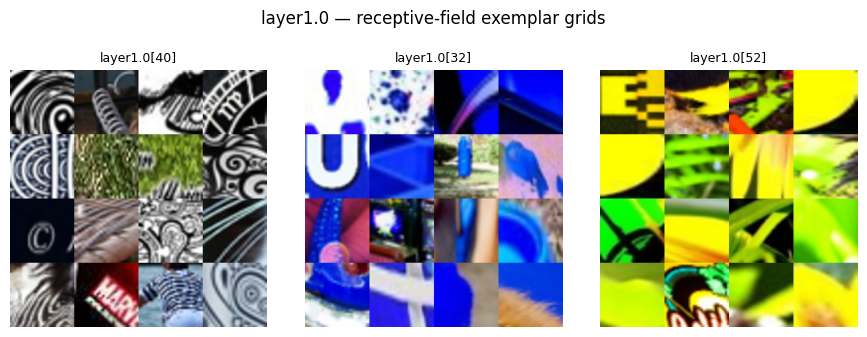

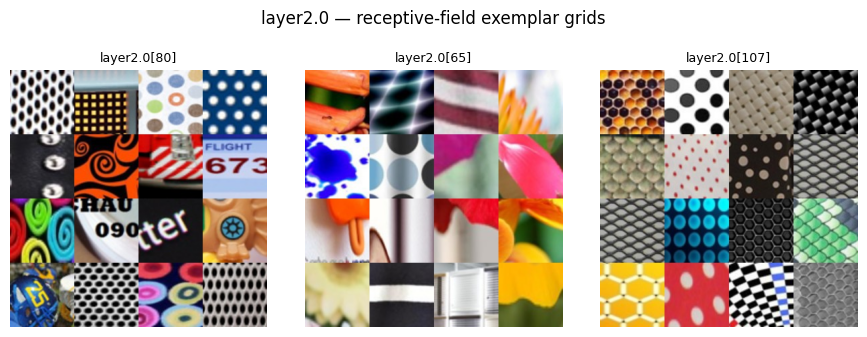

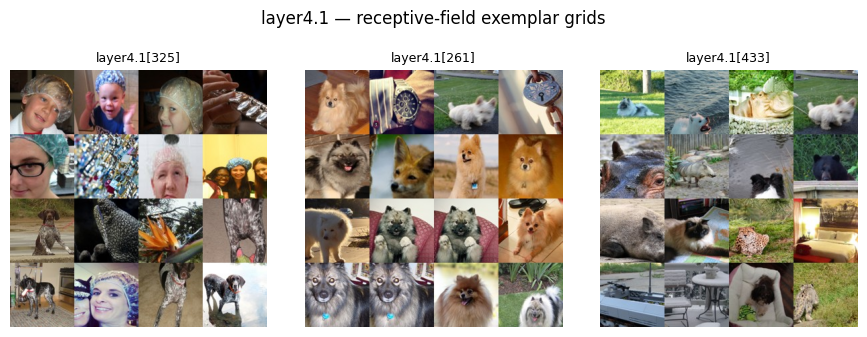

In [ ]:
import matplotlib.pyplot as plt

def show_grids(stage, n=3, seed=0):
    rng = np.random.default_rng(seed)
    chans = rng.choice(STAGE_C[stage], n, replace=False)
    fig, axes = plt.subplots(1, n, figsize=(n * 3, 3.2))
    for ax, c in zip(np.atleast_1d(axes), chans):
        ax.imshow(Image.open(grid_path(stage, int(c))))
        ax.set_title(f"{stage}[{c}]", fontsize=9); ax.axis("off")
    fig.suptitle(f"{stage} — receptive-field exemplar grids", y=1.04)
    plt.tight_layout(); plt.show()

show_grids("layer1.0", 3)   # should be strikingly coherent colours/textures
show_grids("layer2.0", 3)
show_grids("layer4.1", 3)   # object-ish


## 6. Contact sheet + acceptance verdict

One overview image (a random unit per stage) for the write-up, then the PASS/FAIL check
that every unit has a grid.

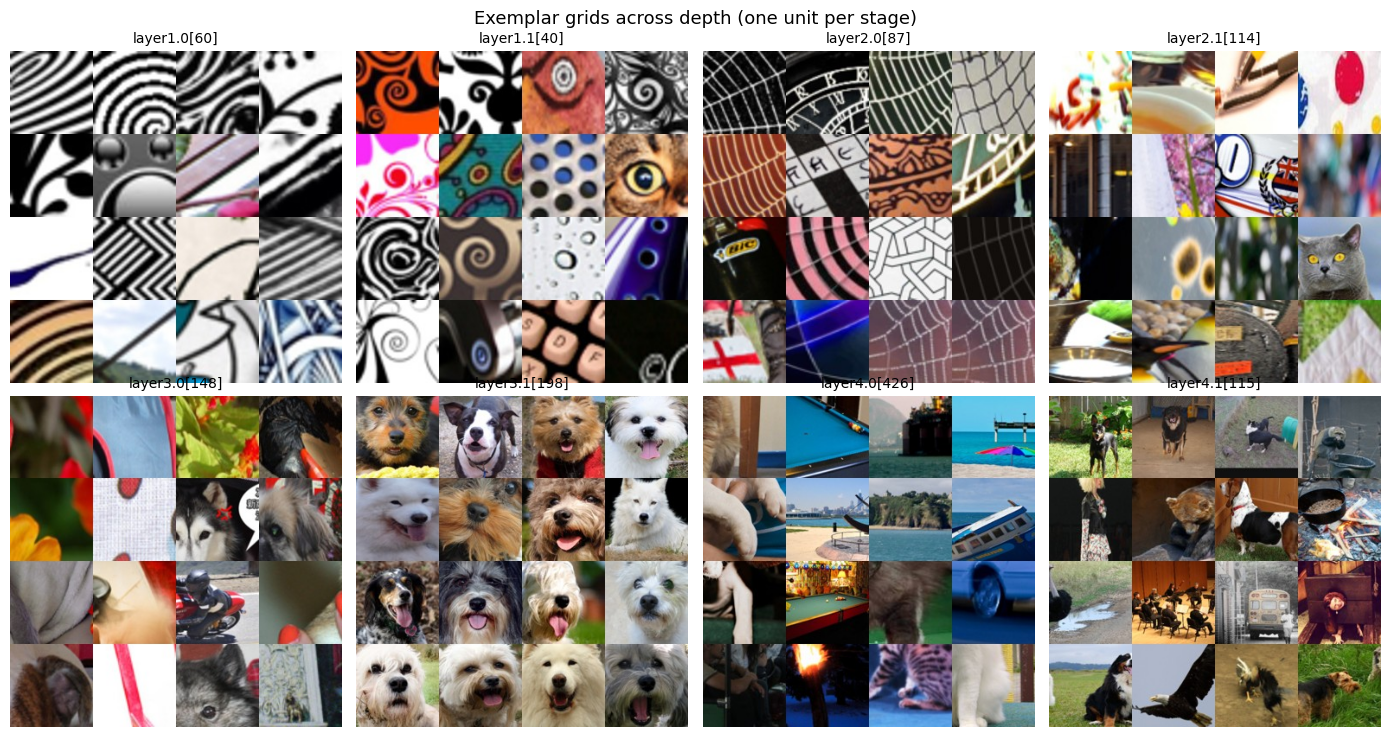

saved /content/drive/MyDrive/cnn_watch_vs_do/results/figures/exemplar_contact_sheet.png
  [PASS] all 1920 unit grids exist  (1920/1920 grids)
  [PASS] top-16 covers all 8 stages  (1920/1920 grids)
  [PASS] contact sheet saved  (1920/1920 grids)

WEEK 2 COMPLETE — commit; week 3 is the two labelers.


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7.5))
rng = np.random.default_rng(7)
for ax, stage in zip(axes.flat, STAGES):
    c = int(rng.integers(STAGE_C[stage]))
    ax.imshow(Image.open(grid_path(stage, c)))
    ax.set_title(f"{stage}[{c}]", fontsize=10); ax.axis("off")
fig.suptitle("Exemplar grids across depth (one unit per stage)", y=0.98, fontsize=13)
plt.tight_layout()
contact = RESULTS / "figures" / "exemplar_contact_sheet.png"
plt.savefig(contact, dpi=110, bbox_inches="tight"); plt.show()
print("saved", contact)

n_expected = CONFIG["n_units"]
n_have = sum(grid_path(s, c).exists() for s in STAGES for c in range(STAGE_C[s]))
checks = {
    f"all {n_expected} unit grids exist": n_have == n_expected,
    "top-16 covers all 8 stages": all(s in vals for s in STAGES),
    "contact sheet saved": contact.exists(),
}
for k, v in checks.items():
    print(f"  [{'PASS' if v else 'FAIL'}] {k}  ({n_have}/{n_expected} grids)")
print("\nWEEK 2 " + ("COMPLETE " if all(checks.values())
      else "INCOMPLETE — fix the FAIL above (usually: rerun 01 for all 8 stages)."))
